# Practica para flujo de fluidos incompresibles

In [18]:
import numpy as np

In [19]:
def calculo_Fd(rugosidad, D_interno, Reynolds):
    proporcion = rugosidad / D_interno
    
    if Reynolds < 2300:
        return 64/Reynolds
    
    A = ((proporcion/3.71)+(14.5/Reynolds))
    B = (5.02/Reynolds) * np.log10(A)
    C = (proporcion/3.71) - B
    D = -2 * np.log10(C)
    Fd = D**(-2)
    
    return Fd

# | Flujo en 2 fases |

### Calcule la caída de presión real en el tubo interior de un intercambiador de calor de <br> hierro galvanizado D.N. 5 inch Sch 80 (rugosidad 0,15 mm, D interno 0,1222m )<br> y 3 m de longitud, que conduce vapor en régimen turbulento y se sabe que las pérdidas de presión <br> considerando solo el vapor son 5 psi. Suponga que, debido a la condensación del vapor se genera agua <br> en fase liquida que circula conjuntamente con el vapor hasta salir del intercambiador,<br> con un flujo másico de 10 kg/h. Viscosidad del agua 1 cP.

In [20]:
# Datos

L = 3.0                      # m
D_interno = 0.1222           # m (DN 5" Sch 80) 
eps = 0.15e-3                # m

deltaP_vapor = 5 * 6894.76   # Pa

m_dot_L = 10 / 3600          # kg/s
rho_L = 1000                 # kg/m³
mu_L = 1e-3                  # Pa.s

# Área
A = np.pi * D_interno**2 / 4

# Velocidad agua
Q_L = m_dot_L / rho_L
V_L = Q_L / A

# Reynolds
Re = rho_L * V_L * D_interno / mu_L

# Factor de fricción (Swamee-Jain)
f = calculo_Fd(eps, D_interno, Re)

# Caída de presión agua sola
deltaP_L = (f *(L/D_interno) *(rho_L * V_L**2 / 2))

# Parámetro de Martinelli
X = np.sqrt(deltaP_L / deltaP_vapor)

# Asumimos regimen flujo burbuja
mL_A = m_dot_L/A
phi = 14.2 * X**0.75 / (mL_A**0.1)

# Caída de presión bifásica
deltaP_real = phi * deltaP_vapor

print(f"Área                 = {A:.6f} m²")
print(f"Velocidad agua       = {V_L:.6e} m/s")
print(f"Reynolds agua        = {Re:.2f}")
print(f"Factor fricción      = {f:.5f}")
print(f"ΔP agua              = {deltaP_L/6894.76:.6f} psi")
print(f"Martinelli X         = {X:.6f}")
print(f"Φ                    = {phi:.4f}")
print(f"ΔP bifásica          = {deltaP_real/6894.76:.4f} psi")

Área                 = 0.011728 m²
Velocidad agua       = 2.368455e-04 m/s
Reynolds agua        = 28.94
Factor fricción      = 2.21128
ΔP agua              = 0.000000 psi
Martinelli X         = 0.000210
Φ                    = 0.0286
ΔP bifásica          = 0.1431 psi


# Se tiene un sistema vapor y su condensado que están fluyendo por una tubería de D.N. 2 inch Sch 80. Se quiere minimizar el flujo de condensado,<br> ya que perjudica la eficiencia de los intercambiadores. Basándose en el diagrama de Baker. :

### 1. ¿Cuál es el régimen de flujo caracterizado por mayor relación volumétrica de gas? 
### 2. ¿Como sugiere usted que sea el flujo másico de vapor en relación al flujo másico del condensado? 
### 3. Si se aumenta la presión del vapor ¿Que efecto se tiene en las características del flujo?

### Respuestas


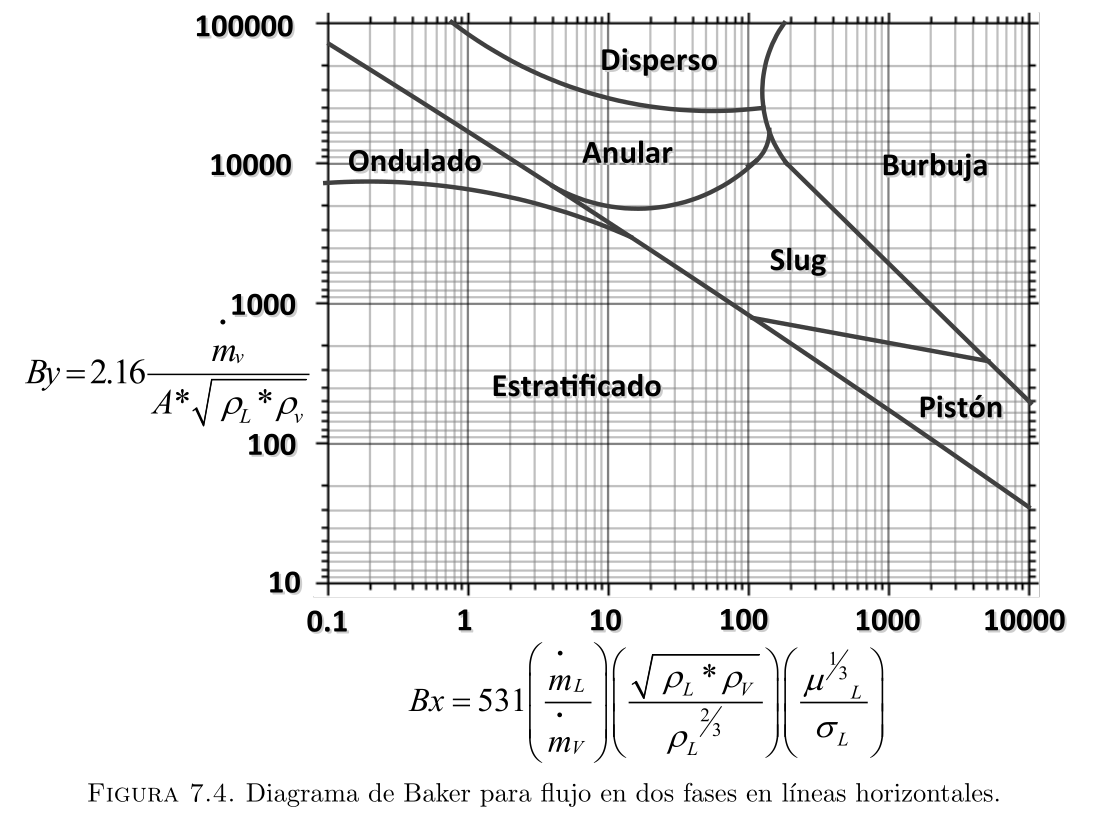

1. El régimen anular. En este régimen el vapor constituye la fase continua y ocupa prácticamente toda la sección transversal de la tubería, mientras que el condensado circula como una película delgada adherida a la pared. Este régimen minimiza la acumulación de condensado y favorece la eficiencia de los intercambiadores de calor.
2. el flujo másico de vapor debe ser mucho mayor que el flujo másico del condensado. De esta manera el vapor permanece como fase continua y el condensado se transporta como una película delgada sobre la pared, favoreciendo el régimen anular (se favorece aumentando temperatura o disminuyendo la presión de entrada del vapor)

# Responda verdadero o falso y justifique.
### “Para calcular la caída de presión real de un gas fluyendo en un flujo multifásico se considera que esta es totalmente independiente de la caída de presión real que tenga el líquido que fluye con él.”

Falso. En flujo multifásico la caída de presión de una fase depende de la interacción con la otra fase. La presencia del líquido modifica el patrón de flujo, el deslizamiento (slip), la fricción y el intercambio de cantidad de movimiento con el gas. Por ello, la caída de presión real del gas no puede calcularse independientemente de la del líquido, sino mediante correlaciones bifásicas como las de Lockhart-Martinelli o Kern, que consideran la interacción entre ambas fases

# Enuncie dos ejemplos industriales de flujo multifásico.

- Transporte de petróleo, gas natural y agua desde pozos petroleros hasta las plantas de separación.
- Flujo de vapor y condensado en intercambiadores de calor, calderas y líneas de distribución de vapor.

# Considere un flujo bifásico vapor de agua/agua en una línea de servicio que llega a un intercambiador de calor <br> 
### ¿Cuál es el régimen de flujo deseable en este sistema?<br>
### ¿Qué sucede si se instala una reducción en una tubería por donde pasa?<br>
### Explique basándose en el diagrama de Baker cuando se tienen flujos másicos de líquidos bajos

El régimen anular, ya que en este régimen el vapor constituye la fase continua y el condensado circula como una película delgada adherida a la pared de la tubería. Esto minimiza la acumulación de condensado y mejora la eficiencia de la transferencia de calor en el intercambiador.

Al instalar una reducción disminuye el área transversal de la tubería. Como el flujo másico se conserva $\dot{m} = \rho AV$ la velocidad del vapor aumenta al disminuir el área de flujo.

El incremento de velocidad aumenta la capacidad del vapor para arrastrar el condensado, favoreciendo el transporte de la fase líquida como película o gotas finas. Sin embargo, la reducción también incrementa la caída de presión local y, si la velocidad es excesiva, puede aumentar el arrastre de gotas (entrainment), la erosión y las pérdidas de carga.

En el diagrama de Baker, cuando el flujo másico del líquido es bajo y el flujo de vapor es predominante, el punto de operación en el diagrama de Baker se desplaza hacia las regiones de mayor predominio del gas. Bajo estas condiciones se favorecen los regímenes anular y, para velocidades muy altas del vapor, el régimen disperso. Estos regímenes presentan una menor acumulación de condensado dentro de la tubería y son los más convenientes para líneas de vapor que alimentan intercambiadores de calor.

# | Flujo Externo |

# Se quiere tratar el agua de un rio mediante un sedimentador primario. <br> Mediante pruebas experimentales en cilindros graduados, se encuentra que la velocidad <br> de sedimentación impedida para las partículas sólidas del agua en el punto A del rio es <br>0,2 cm/min.<br> Aguas arriba, en el punto B, la misma prueba arroja una velocidad de sedimentación es de 0,8 cm/min.<br> ¿De dónde sugiere que se tome el agua para ser tratada? Escoja punto A o B y justifique.

La velocidad de sedimentación impedida en el punto B es mayor:

$V_{s,B} = 0.8\frac{cm}{min}$

mientras que en el punto A es

$V_{s,A} = 0.2 \frac{cm}{min}$

Una mayor velocidad de sedimentación indica que las partículas suspendidas descienden más rápidamente por acción de la gravedad. En consecuencia, el sedimentador requiere menor tiempo de residencia y presenta una mayor eficiencia para separar los sólidos del agua. Por el contrario, en el punto A las partículas sedimentan cuatro veces más lentamente, lo que implica un proceso de separación menos eficiente y la necesidad de un sedimentador de mayor tamaño o de un mayor tiempo de retención.

Port lo tanto, se recomienda captar el agua en el punto B, ya que las partículas presentan una velocidad de sedimentación impedida mayor (0.8 cm/min), favoreciendo una separación más rápida y eficiente de los sólidos en el sedimentador primario.

# Responda Verdadero o falso y justifique 
### “La magnitud de la velocidad terminal de sedimentación de una partícula dentro de un fluido es independiente de la presencia de otras partículas dentro del fluido.”

Falso.

La velocidad terminal de sedimentación depende de la concentración de partículas en el fluido. Cuando una partícula sedimenta aislada se obtiene la velocidad terminal libre. Sin embargo, cuando existen muchas partículas, éstas interactúan entre sí y con el fluido, aumentando la resistencia al movimiento y disminuyendo la velocidad de sedimentación. Este fenómeno se conoce como sedimentación impedida o sedimentación en suspensión.

# Seleccione la respuesta correcta y justifique.
### Se quiere diseñar el sedimentador para dos tipos de sistemas de partículas con diferente velocidad terminal (velocidad máxima de sedimentación). El sedimentador de mayor área será para aquel sistema que: 

### a) Presente una velocidad terminal mayor <br>
### b) Presente una velocidad terminal menor <br>
### c) No es relevante la velocidad terminal en el diseño de un sedimentador

El área de un sedimentador es inversamente proporcional a la velocidad terminal de sedimentación,

$A = \frac{Q}{V_t}$	​


donde:

A: área superficial del sedimentador.
Q: caudal de alimentación.
V_t : velocidad terminal de sedimentación.

Por tanto, si las partículas sedimentan más lentamente (menor $V_t$), se requiere un área mayor para garantizar su remoción antes de que abandonen el sedimentador. Por el contrario, una mayor velocidad terminal permite diseñar un sedimentador de menor área.

### Calcule la viscosidad de un aceite si se sabe que una esfera de 2 cm de diámetro y densidad 9 g/cm3 tarda 3 segundos en caer 30 cm en un cilindro que contiene el aceite. La densidad del aceite se mide en un experimento separadamente. Se encuentra que 50ml de aceite pesan 42 g.

In [ ]:
g = 9.81                     # m/s²

# Esfera
d = 0.02                     # m
rho_p = 9000                 # kg/m³

# Aceite
masa = 42e-3                 # kg
volumen = 50e-6              # m³
rho_f = masa / volumen       # kg/m³

# Ensayo
distancia = 0.30             # m
tiempo = 3                   # s

v = distancia / tiempo       # m/s


mu = ((rho_p - rho_f) * g * d**2) / (18 * v)
Re = rho_f * v * d / mu

print(f"Densidad aceite       = {rho_f:.2f} kg/m³")
print(f"Velocidad terminal    = {v:.4f} m/s")
print(f"Viscosidad            = {mu:.4f} Pa·s")
print(f"Reynolds partícula    = {Re:.4f}")

# Información de repaso ley de stokes
if Re < 1:
    print("\nSe cumple Re < 1.")
    print("La hipótesis de Stokes es válida.")
else:
    print("\nRe > 1.")
    print("La ecuación de Stokes NO es válida.")
    print("Debe utilizarse la formulación general con Cd.")

Densidad aceite       = 840.00 kg/m³
Velocidad terminal    = 0.1000 m/s
Viscosidad            = 17.7888 Pa·s
Reynolds partícula    = 0.0944

Se cumple Re < 1.
La hipótesis de Stokes es válida.


### En una industria papelera se quiere diseñar un proceso para sacar el agua de un rio aledaño y pre-tratar 5 m3/h de agua para utilizarla después en el proceso. Después de una discusión con los ingenieros de planta se definió que usted realizara los cálculos necesarios para determinar cuál de las tecnologías resulta más económica para realizar este pre-tratamiento. En la planta hay disponibilidad de un área de 8 m2 para instalar el equipo necesario. 

#### Las tecnologías elegidas son 
#### a) Un proceso de Sedimentación. Se sabe que Velocidad terminal de sedimentación agua sola= 0,2 cm/min .Velocidad terminal de sedimentación con polímero= 1,406 cm/min. 
1. Calcule el área del sedimentador necesaria para el agua sola.<br>
2. Calcule el área del sedimentador necesaria para el agua con polímero.<br>
3. Cuál de los dos casos puede ser utilizado en la planta?<br>

#### b) Equipo de filtrado. A la empresa han ofrecido un filtro prensa que opera a presión constante de 80 psi con lo cual se obtienen 1800 galones de filtrado en una hora. El tiempo de parada y limpieza del filtro es de 15 minutos y se realiza en forma automática. El costo de este equipo es de 40 millones de pesos y ocupa un espacio de 4,5 m2. 

4. El filtro ofrecido cumple con las especificaciones de espacio disponible y del caudal requerido en la planta? Tener en cuenta que el tiempo total de operación= tiempo de limpieza + tiempo de filtrado.<br>
5. Selección. Si el costo de construcción de un tanque de sedimentación es de un millón quinientos por m2, Cual de las dos tecnologías recomendara usted a la junta de la empresa papelera?<br>

### Respuesta punto 5:
La alternativa recomendada es el sedimentador con adición de polímero porque:

- Cumple con el área disponible (5.93 m² < 8 m²).
- Tiene un costo aproximado de 8.90 millones de pesos.
- El filtro prensa también cumple con el caudal y el espacio, pero su costo es de 40 millones de pesos.
- El sedimentador sin polímero no es viable porque requiere 41.67 m², muy por encima del área disponible.

Por tanto, la tecnología más económica y que satisface las restricciones de diseño es el sedimentador con adición de polímero.

In [ ]:
# Datos
Q = 5 / 3600            # m³/s
A_disponible = 8        # m²

# Velocidades terminales
vt_agua = (0.2 / 100) / 60
vt_polimero = (1.406 / 100) / 60

# Áreas requeridas
A_agua = Q / vt_agua
A_polimero = Q / vt_polimero

print(f"Área agua sola      = {A_agua:.2f} m²")
print(f"Área con polímero   = {A_polimero:.2f} m²")

print()

print("RTA1 : Agua sola:", "Cumple" if A_agua <= A_disponible else "No cumple")
print("RTA2 : Con polímero:","Cumple" if A_polimero <= A_disponible else "No cumple")
print("RTA3 : Sólo el sedimentador con polímero puede instalarse porque requiere menos de los 8 m² disponibles.")

# ===

gal_filtrado = 1800

t_filtrado = 60       # min
t_limpieza = 15       # min

A_filtro = 4.5        # m²

# Tiempo de ciclo
t_total = t_filtrado + t_limpieza

# Producción efectiva
Q_gal_h = gal_filtrado * 60 / t_total
Q_m3_s = (Q_gal_h * 3.78541 / 1000) * (1/3600)

print(f"\nRTA4 : Caudal efectivo = {Q_m3_s:.5f} m³/s ; {Q_m3_s * 3600:.2f} m³/h")
print("Espacio:","Cumple" if A_filtro <= A_disponible else "No cumple")
print("Caudal:","Cumple" if Q_m3_s >= Q else "No cumple")

# ===

costo_m2 = 1.5      # millones de pesos

costo_sed_agua = costo_m2 * A_agua
costo_sed_pol = costo_m2 * A_polimero

costo_filtro = 40

print(f"\nSedimentador agua sola : {costo_sed_agua:.2f} millones")
print(f"Sedimentador polímero  : {costo_sed_pol:.2f} millones")
print(f"Filtro prensa          : {costo_filtro:.2f} millones")

Área agua sola      = 41.67 m²
Área con polímero   = 5.93 m²

RTA1 : Agua sola: No cumple
RTA2 : Con polímero: Cumple
RTA3 : Sólo el sedimentador con polímero puede instalarse porque requiere menos de los 8 m² disponibles.

 RTA4 : Caudal efectivo = 0.00151 m³/s ; 5.45 m³/h
Espacio: Cumple
Caudal: Cumple
Sedimentador agua sola : 62.50 millones
Sedimentador polímero  : 8.89 millones
Filtro prensa          : 40.00 millones
